In [5]:
!pip install gymnasium

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [6]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [7]:
class HappinessEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self):
        super(HappinessEnv, self).__init__()
        self.grid_size = (5, 5)  
        self.num_states = self.grid_size[0] * self.grid_size[1]
        self.action_space = spaces.Discrete(4)  
        self.observation_space = spaces.Box(
            low=0, high=max(self.grid_size), shape=(2,), dtype=np.int32
        )  

        self.goal_state = (4, 4)  

        self.rewards = np.zeros(self.grid_size)
        self.rewards[4, 4] = 50
        self.rewards[2, 2] = -5  
        self.rewards[1, 1] = -3  
        self.rewards[3, 3] = 20

        self.reward_positions = {
            (4, 4): 'img/best.png',  
            (3, 3): 'img/happy.png',  
        }
        self.penalty_positions = {
            (2, 2): 'img/sad.png',   
            (1, 1): 'img/sad.png',  
        }

        self.state = None

    def reset(self, seed=None):
        """
        Reset the environment to the initial state.
        """
        super().reset(seed=seed)
        self.state = (0, 0)  
        return np.array(self.state, dtype=np.int32), {}

    def step(self, action):
        """
        Execute one timestep within the environment.
        """
        if action not in range(4):  
            raise ValueError(f"Invalid action: {action}")

        i, j = self.state
        if action == 0:  # Up
            next_state = (max(0, i - 1), j)
        elif action == 1:  # Down
            next_state = (min(self.grid_size[0] - 1, i + 1), j)
        elif action == 2:  # Right
            next_state = (i, min(self.grid_size[1] - 1, j + 1))
        elif action == 3:  # Left
            next_state = (i, max(0, j - 1))
        else:
            raise ValueError(f"Unexpected action: {action}")

        self.state = next_state
        reward = self.rewards[next_state]
        found = self.state == self.goal_state
        return np.array(self.state, dtype=np.int32), reward, found

    def render(self):
        """
        Visualize the grid-world environment.
        """
        fig, ax = plt.subplots()
        ax.set_xticks(np.arange(self.grid_size[1] + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(self.grid_size[0] + 1) - 0.5, minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

        grid_colors = np.zeros(self.grid_size)  
        ax.imshow(grid_colors, cmap="Blues", origin='upper')

        scale_factor = 0.5
        for position, img_name in self.reward_positions.items():
            img = mpimg.imread(img_name)
            cell_center_x = position[1]
            cell_center_y = position[0]
            img_extent = [
                cell_center_x - 0.5 * scale_factor, cell_center_x + 0.5 * scale_factor,
                cell_center_y + 0.5 * scale_factor, cell_center_y - 0.5 * scale_factor
            ]
            ax.imshow(img, extent=img_extent, zorder=2, aspect="auto")

        for position, img_name in self.penalty_positions.items():
            img = mpimg.imread(img_name)
            cell_center_x = position[1]
            cell_center_y = position[0]
            img_extent = [
                cell_center_x - 0.5 * scale_factor, cell_center_x + 0.5 * scale_factor,
                cell_center_y + 0.5 * scale_factor, cell_center_y - 0.5 * scale_factor
            ]
            ax.imshow(img, extent=img_extent, zorder=2, aspect="auto")

        # Plot the agent
        agent_x, agent_y = self.state[1], self.state[0]
        ax.plot(agent_x, agent_y, 'o', color='blue', markersize=20, label='Agent')

        ax.set_title("Find Happiness")
        plt.legend(loc='upper right')
        plt.show()

Initial State of the Environment:


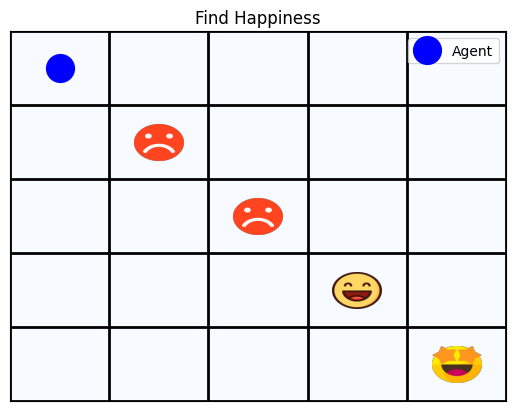

Current Position: [0 0], Action: Up, Reward: 0.0


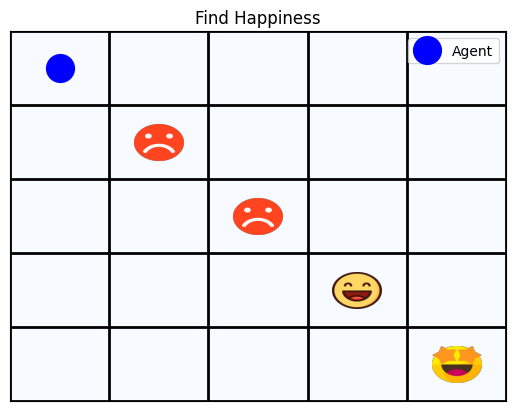

Current Position: [1 0], Action: Down, Reward: 0.0


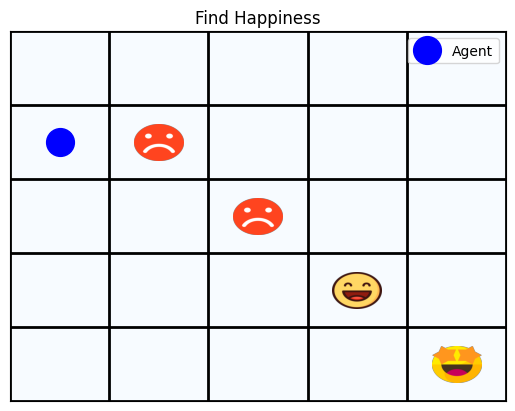

Current Position: [0 0], Action: Up, Reward: 0.0


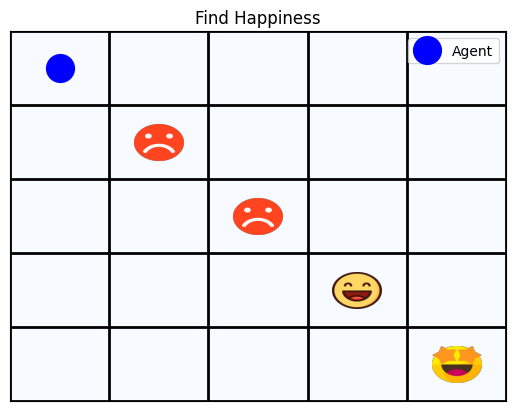

Current Position: [0 0], Action: Left, Reward: 0.0


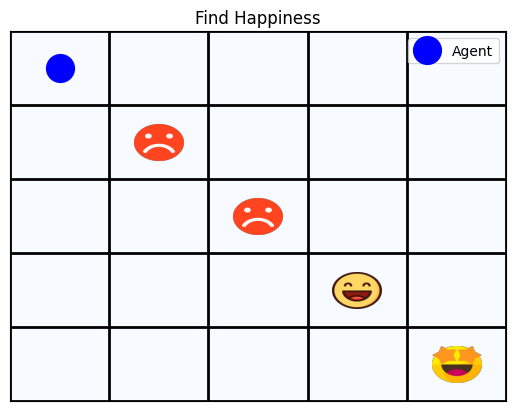

Current Position: [0 0], Action: Up, Reward: 0.0


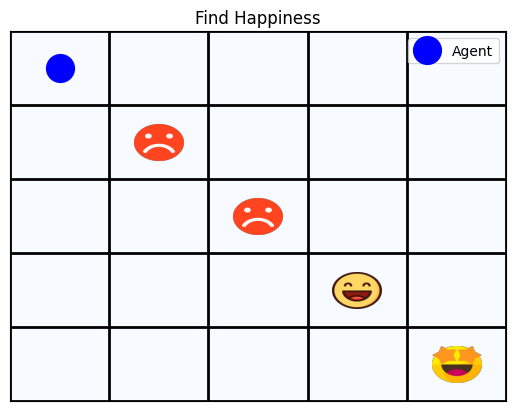

Current Position: [1 0], Action: Down, Reward: 0.0


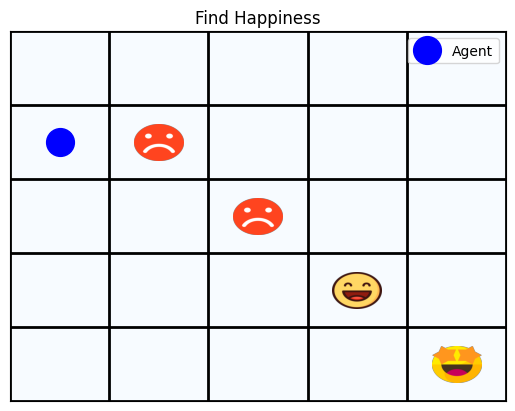

Current Position: [1 0], Action: Left, Reward: 0.0


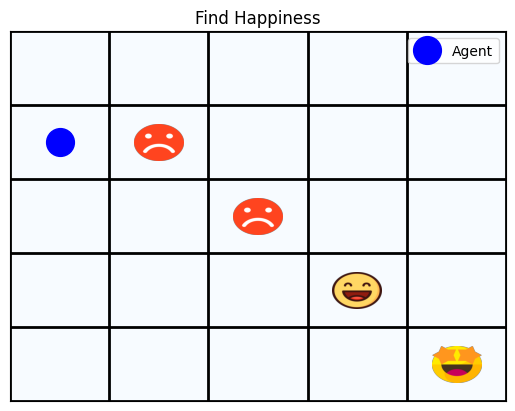

Current Position: [1 1], Action: Right, Reward: -3.0


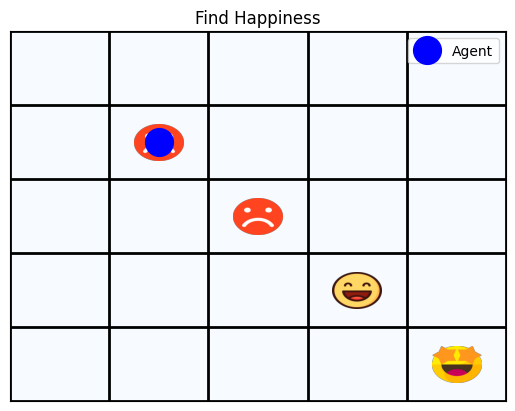

Current Position: [0 1], Action: Up, Reward: 0.0


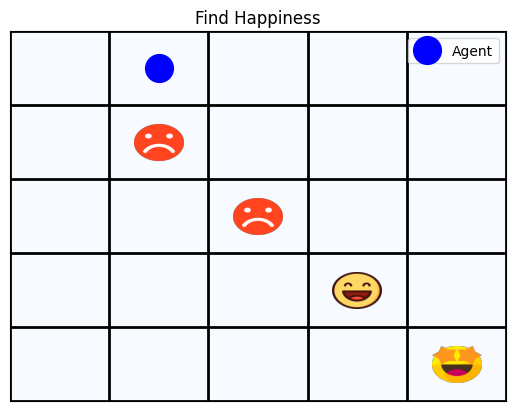

Current Position: [0 1], Action: Up, Reward: 0.0


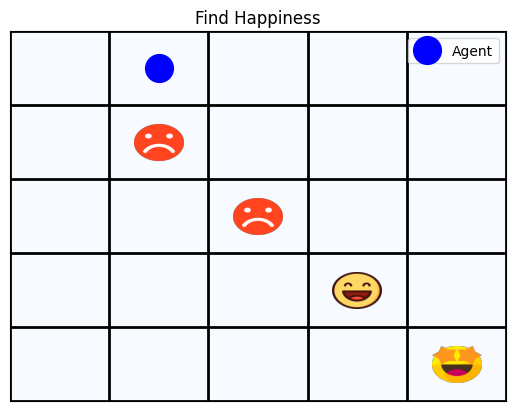

In [8]:
env = HappinessEnv()
obs, _ = env.reset()
print("Initial State of the Environment:")
env.render()
action_map = {
    0: "Up",
    1: "Down",
    2: "Right",
    3: "Left"
}

# Take 10 random steps
for _ in range(10):
    action = env.action_space.sample()
    obs, reward, found = env.step(action)
    print(f"Current Position: {obs}, Action: {action_map[action]}, Reward: {reward}")
    env.render()
    if found:
        print("Treasure found!")
        break